In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

In [2]:
orders = pd.read_csv("../data/orders.csv")
order_details = pd.read_csv("../data/order_details.csv")
pizzas = pd.read_csv("../data/pizzas.csv")
pizza_types = pd.read_csv("../data/pizza_types.csv")

In [3]:
print(orders.shape)
print(order_details.shape)
print(pizzas.shape)
print(pizza_types.shape)

(21350, 3)
(48620, 4)
(96, 4)
(32, 4)


In [4]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [5]:
df = order_details.merge(
    pizzas,
    on="pizza_id"
)

df = df.merge(
    pizza_types,
    on="pizza_type_id"
)

df.head()

,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [6]:
df["revenue"] = df["quantity"] * df["price"]

df.head()

,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,revenue
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


In [7]:
total_revenue = df["revenue"].sum()

print(f"Total Revenue = ${total_revenue:,.2f}")

Total Revenue = $817,860.05


In [8]:
total_pizzas = df["quantity"].sum()

print("Total Pizzas Sold:", total_pizzas)

Total Pizzas Sold: 49574


In [9]:
category_revenue = (
    df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Classic    220053.10
Supreme    208197.00
Chicken    195919.50
Veggie     193690.45
Name: revenue, dtype: float64

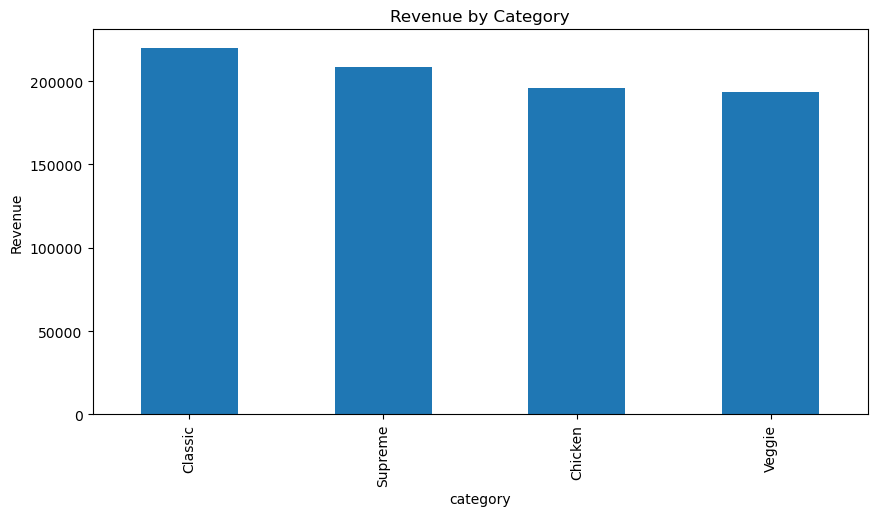

In [10]:
category_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

In [11]:
size_revenue = (
    df.groupby("size")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

size_revenue

size
L      375318.70
M      249382.25
S      178076.50
XL      14076.00
XXL      1006.60
Name: revenue, dtype: float64

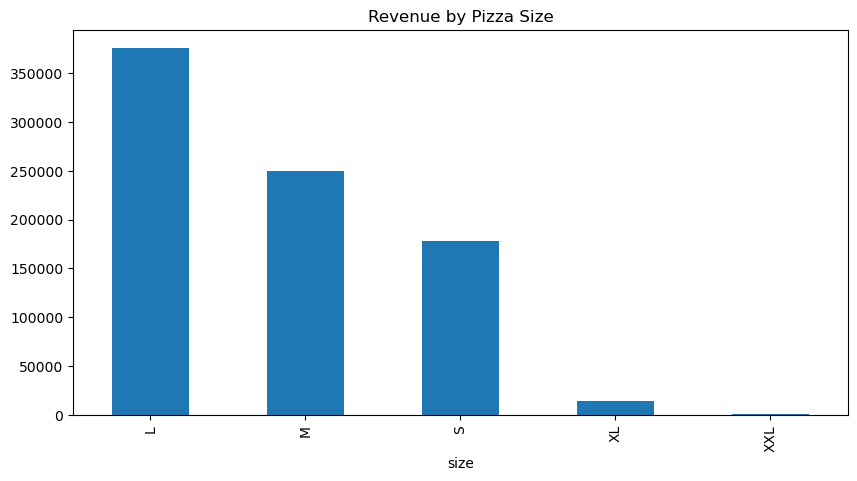

In [12]:
size_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Pizza Size")
plt.show()

In [13]:
top10 = (
    df.groupby("name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10

name
The Thai Chicken Pizza          43434.25
The Barbecue Chicken Pizza      42768.00
The California Chicken Pizza    41409.50
The Classic Deluxe Pizza        38180.50
The Spicy Italian Pizza         34831.25
The Southwest Chicken Pizza     34705.75
The Italian Supreme Pizza       33476.75
The Hawaiian Pizza              32273.25
The Four Cheese Pizza           32265.70
The Sicilian Pizza              30940.50
Name: revenue, dtype: float64

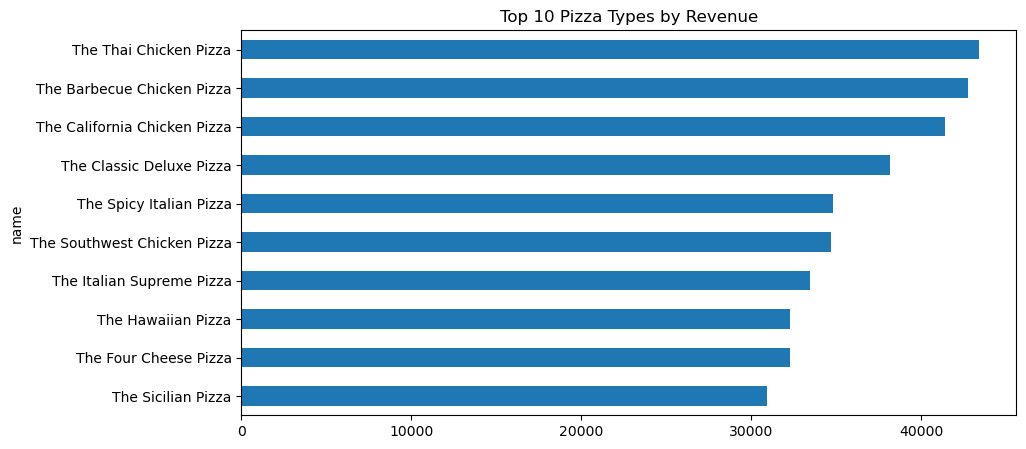

In [14]:
top10.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Pizza Types by Revenue")
plt.show()

In [ ]:
# Check columns
print(orders.columns)

# Convert date column to datetime
orders["date"] = pd.to_datetime(orders["date"])

# Verify
orders.info()
orders.head()

Index(['order_id', 'date', 'time'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  21350 non-null  int64         
 1   date      21350 non-null  datetime64[ns]
 2   time      21350 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 500.5+ KB


,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [18]:
df = df.merge(
    orders,
    on="order_id"
)

In [24]:
df["date"] = pd.to_datetime(df["date"])

monthly_revenue = (
    df.groupby(df["date"].dt.month)["revenue"]
      .sum()
)

monthly_revenue

date
1     69793.30
2     65159.60
3     70397.10
4     68736.80
5     71402.75
6     68230.20
7     72557.90
8     68278.25
9     64180.05
10    64027.60
11    70395.35
12    64701.15
Name: revenue, dtype: float64

In [26]:
revenue_percent = (
    df.groupby("category")["revenue"]
    .sum()
)

revenue_percent = (
    revenue_percent /
    revenue_percent.sum()
) * 100

revenue_percent

category
Chicken    23.955138
Classic    26.905960
Supreme    25.456311
Veggie     23.682591
Name: revenue, dtype: float64

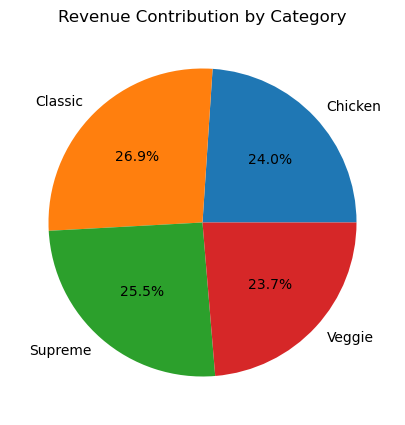

In [27]:
revenue_percent.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Revenue Contribution by Category"
)

plt.ylabel("")
plt.show()

In [28]:
pizza_category = (
    df.groupby(
        ["category","name"]
    )["revenue"]
    .sum()
    .reset_index()
)

pizza_category["rank"] = (
    pizza_category.groupby("category")
    ["revenue"]
    .rank(
        method="dense",
        ascending=False
    )
)

top3 = pizza_category[
    pizza_category["rank"] <= 3
]

top3.sort_values(
    ["category","rank"]
)

,category,name,revenue,rank
5,Chicken,The Thai Chicken Pizza,43434.25,1.0
0,Chicken,The Barbecue Chicken Pizza,42768.00,2.0
1,Chicken,The California Chicken Pizza,41409.50,3.0
7,Classic,The Classic Deluxe Pizza,38180.50,1.0
9,Classic,The Hawaiian Pizza,32273.25,2.0
12,Classic,The Pepperoni Pizza,30161.75,3.0
21,Supreme,The Spicy Italian Pizza,34831.25,1.0
16,Supreme,The Italian Supreme Pizza,33476.75,2.0
19,Supreme,The Sicilian Pizza,30940.50,3.0
24,Veggie,The Four Cheese Pizza,32265.70,1.0


In [31]:
df.to_csv("final_merged_dataset.csv", index=False)